In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-darkgrid')

# CRUspi Longs
df_long = pd.read_csv('../data/crulong_ObservationData_ruzmvmb.csv')
df_long = df_long[['Date', 'Value']].rename(columns={'Value': 'cruspi_longs'})
df_long['date'] = pd.to_datetime(
    df_long['Date'].str.replace(r'(\d{4})M(\d+)', r'\1-\2-01', regex=True))
df_long = df_long[['date', 'cruspi_longs']].sort_values('date').reset_index(drop=True)

# CRUspi Asia
df_asia = pd.read_excel('../data/Cruasia-data.xlsx')
df_asia = df_asia.rename(columns={'Date': 'date', 'CRUspi Asia': 'cruspi_asia'})
df_asia['date'] = pd.to_datetime(df_asia['date'])
df_asia = df_asia.sort_values('date').reset_index(drop=True)

print(f"CRUspi Asia:  {df_asia.shape[0]} meses | {df_asia['date'].min().strftime('%b %Y')} → {df_asia['date'].max().strftime('%b %Y')}")
print(f"CRUspi Longs: {df_long.shape[0]} meses | {df_long['date'].min().strftime('%b %Y')} → {df_long['date'].max().strftime('%b %Y')}")

CRUspi Asia:  387 meses | Apr 1994 → Jun 2026
CRUspi Longs: 399 meses | Apr 1994 → Jun 2027


In [ ]:
# Resultado de comparación de changepoint_prior_scale
tuning_results = pd.DataFrame({
    'changepoint_prior_scale': [0.05, 0.01, 0.005, 0.001],
    'MAE_Asia':  [26.42, 51.58, 49.91, 50.63],
    'MAPE_Asia': [17.37, 33.80, 32.72, 33.18]
})

print("=== SELECCIÓN DE PARÁMETRO ÓPTIMO ===")
print(tuning_results.to_string(index=False))
print(f"\n→ Parámetro óptimo: changepoint_prior_scale = 0.05")
print(f"→ MAPE mínimo alcanzado: 17.37% (CRUspi Asia)")

BEST_SCALE = 0.05

=== SELECCIÓN DE PARÁMETRO ÓPTIMO ===
 changepoint_prior_scale  MAE_Asia  MAPE_Asia
                   0.050     26.42      17.37
                   0.010     51.58      33.80
                   0.005     49.91      32.72
                   0.001     50.63      33.18

→ Parámetro óptimo: changepoint_prior_scale = 0.05
→ MAPE mínimo alcanzado: 17.37% (CRUspi Asia)


In [ ]:
def forecast_serie(df, col, periodos=18, nombre='', scale=0.05):
    """Entrena Prophet con parámetro óptimo y proyecta N meses."""
    data = df[['date', col]].rename(columns={'date': 'ds', col: 'y'})

    modelo = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=scale,
        seasonality_mode='multiplicative',
        interval_width=0.80
    )
    modelo.add_seasonality(name='ciclo_economico', period=365.25*5, fourier_order=5)
    modelo.fit(data)

    futuro = modelo.make_future_dataframe(periods=periodos, freq='MS')
    pred = modelo.predict(futuro)

    # Gráfico
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(data['ds'], data['y'],
            label='Histórico', color='steelblue', linewidth=1.2)
    pred_future = pred[pred['ds'] > data['ds'].max()]
    ax.plot(pred_future['ds'], pred_future['yhat'],
            label='Forecast', color='tomato', linewidth=2, linestyle='--')
    ax.fill_between(pred_future['ds'],
                    pred_future['yhat_lower'], pred_future['yhat_upper'],
                    color='tomato', alpha=0.2, label='Intervalo confianza 80%')
    ax.axvline(x=data['ds'].max(), color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f'Forecast {nombre} — {periodos} meses (Prophet)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Índice (Abr 1994 = 100)')
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'../outputs/04_forecast_{nombre.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    return modelo, pred

In [ ]:
def backtest(df, col, test_months=12, scale=0.05, nombre='', plot=True):
    """Evalúa precisión del modelo en los últimos N meses."""
    data = df[['date', col]].rename(columns={'date': 'ds', col: 'y'})
    train = data.iloc[:-test_months]
    test  = data.iloc[-test_months:]

    m = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=scale,
        seasonality_mode='multiplicative',
        interval_width=0.80
    )
    m.add_seasonality(name='ciclo_economico', period=365.25*5, fourier_order=5)
    m.fit(train)
    fcst = m.predict(test[['ds']])

    mae  = mean_absolute_error(test['y'], fcst['yhat'])
    mape = mean_absolute_percentage_error(test['y'], fcst['yhat']) * 100

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(test['ds'], test['y'], 'o-', label='Real', color='steelblue')
        ax.plot(fcst['ds'], fcst['yhat'], 'o-', label='Predicho', color='tomato')
        ax.fill_between(fcst['ds'], fcst['yhat_lower'], fcst['yhat_upper'],
                        color='tomato', alpha=0.15)
        ax.set_title(f'Backtest {nombre} — últimos {test_months} meses',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Fecha')
        ax.set_ylabel('Índice')
        ax.legend()
        plt.tight_layout()
        plt.savefig(f'../outputs/05_backtest_{nombre.lower().replace(" ", "_")}.png', dpi=150)
        plt.show()

    return mae, mape

Entrenando modelo CRUspi Asia...


15:12:48 - cmdstanpy - INFO - Chain [1] start processing
15:12:48 - cmdstanpy - INFO - Chain [1] done processing


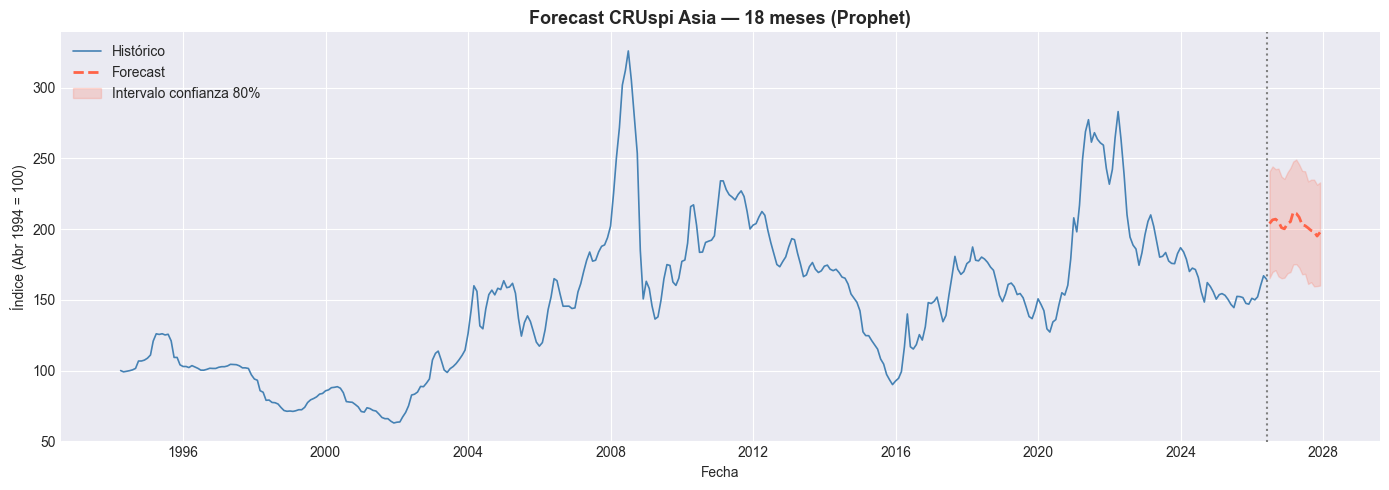

In [ ]:
print("Entrenando modelo CRUspi Asia...")
modelo_asia, pred_asia = forecast_serie(
    df_asia, 'cruspi_asia', periodos=18, nombre='CRUspi Asia', scale=BEST_SCALE)

15:12:49 - cmdstanpy - INFO - Chain [1] start processing


Entrenando modelo CRUspi Longs...


15:12:49 - cmdstanpy - INFO - Chain [1] done processing


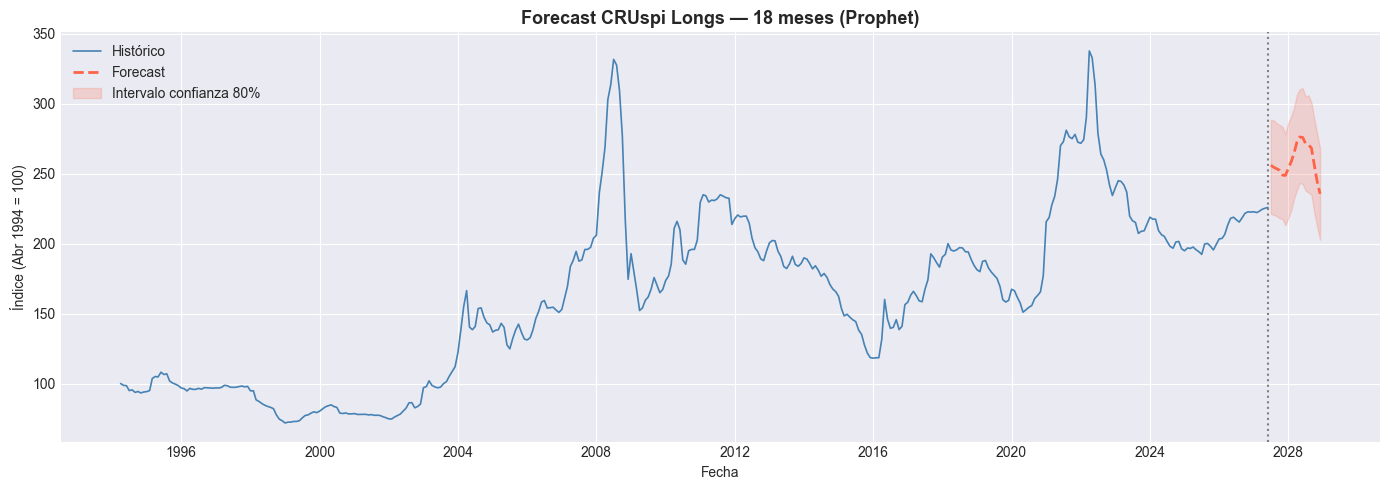

In [ ]:
print("Entrenando modelo CRUspi Longs...")
modelo_longs, pred_longs = forecast_serie(
    df_long, 'cruspi_longs', periodos=18, nombre='CRUspi Longs', scale=BEST_SCALE)

Evaluando precisión...



15:12:51 - cmdstanpy - INFO - Chain [1] start processing
15:12:51 - cmdstanpy - INFO - Chain [1] done processing


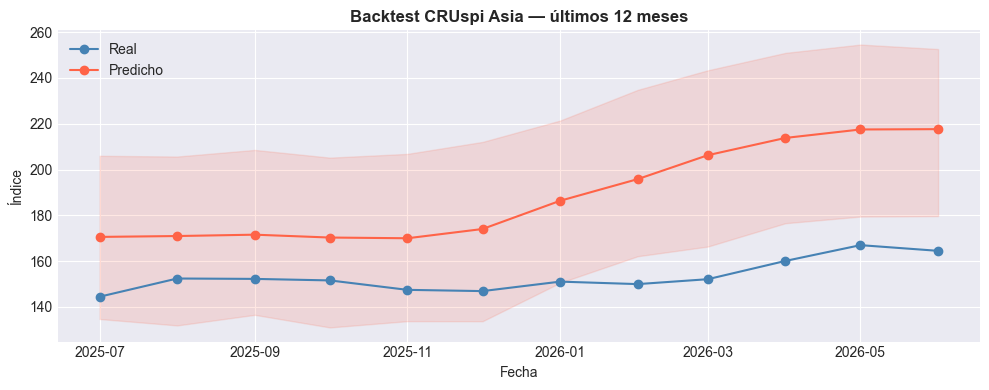

15:12:52 - cmdstanpy - INFO - Chain [1] start processing
15:12:52 - cmdstanpy - INFO - Chain [1] done processing


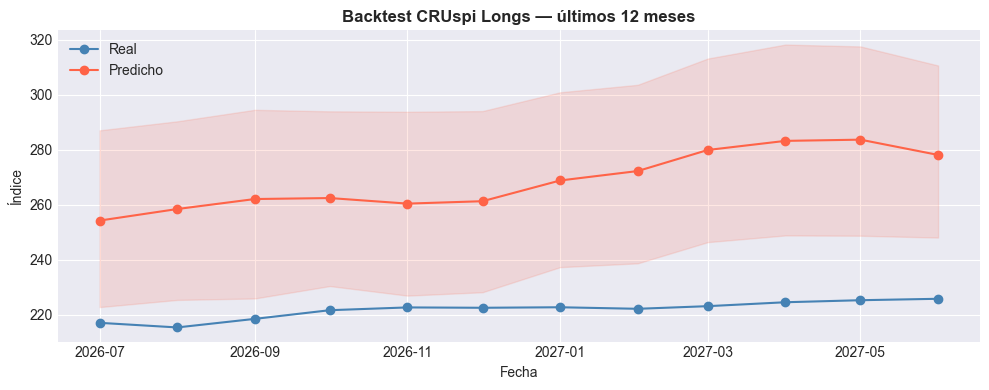


CRUspi Asia  → MAE: 35.41 | MAPE: 22.88%
CRUspi Longs → MAE: 46.99 | MAPE: 21.16%


In [ ]:
print("Evaluando precisión...\n")
mae_asia, mape_asia = backtest(df_asia, 'cruspi_asia',
                                scale=BEST_SCALE, nombre='CRUspi Asia')
mae_longs, mape_longs = backtest(df_long, 'cruspi_longs',
                                  scale=BEST_SCALE, nombre='CRUspi Longs')

print(f"\nCRUspi Asia  → MAE: {mae_asia:.2f} | MAPE: {mape_asia:.2f}%")
print(f"CRUspi Longs → MAE: {mae_longs:.2f} | MAPE: {mape_longs:.2f}%")

In [ ]:
def tabla_forecast(pred, df_original, nombre):
    ultimo = df_original['date'].max() if 'date' in df_original.columns else df_original['ds'].max()
    futuro = pred[pred['ds'] > ultimo][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    futuro.columns = ['Fecha', 'Forecast', 'Límite inferior', 'Límite superior']
    futuro['Fecha'] = futuro['Fecha'].dt.strftime('%b %Y')
    futuro = futuro.round(1).reset_index(drop=True)
    print(f"\n{'='*55}")
    print(f"PROYECCIÓN {nombre.upper()}")
    print(f"{'='*55}")
    print(futuro.to_string(index=False))
    return futuro

tabla_asia  = tabla_forecast(pred_asia,  df_asia,  'CRUspi Asia')
tabla_longs = tabla_forecast(pred_longs, df_long,  'CRUspi Longs')


PROYECCIÓN CRUSPI ASIA
   Fecha  Forecast  Límite inferior  Límite superior
Jul 2026     203.9            165.3            240.7
Aug 2026     206.5            169.7            244.3
Sep 2026     207.0            171.0            242.4
Oct 2026     205.3            166.5            242.8
Nov 2026     201.0            165.2            237.1
Dec 2026     200.2            165.6            235.5
Jan 2027     203.8            168.7            240.0
Feb 2027     205.3            169.7            243.3
Mar 2027     211.9            175.0            247.8
Apr 2027     211.1            175.3            249.2
May 2027     208.4            172.9            245.7
Jun 2027     203.0            168.1            241.2
Jul 2027     202.4            168.4            240.9
Aug 2027     200.8            161.2            233.7
Sep 2027     199.0            162.5            235.0
Oct 2027     198.3            159.5            235.0
Nov 2027     195.1            159.7            231.4
Dec 2027     197.7    

In [ ]:
ultimo_asia  = df_asia['cruspi_asia'].iloc[-1]
ultimo_longs = df_long['cruspi_longs'].iloc[-1]

asia_12m  = pred_asia[pred_asia['ds'] == pred_asia['ds'].max() - pd.DateOffset(months=6)]['yhat'].values[0]
longs_12m = pred_longs[pred_longs['ds'] == pred_longs['ds'].max() - pd.DateOffset(months=6)]['yhat'].values[0]

print("=" * 55)
print("CONCLUSIONES FINALES — PROYECTO CRU STEEL FORECASTING")
print("=" * 55)
print(f"""
DATOS
  Período histórico : Abr 1994 → Jun 2026 (387 meses)
  Series analizadas : CRUspi Asia, CRUspi Longs

CORRELACIÓN (Notebook 02)
  Correlación sin rezago  : r = 0.9572
  Correlación con Lag 1   : r = 0.9580 (óptimo)
  → Asia lidera a Longs por 1 mes

MODELO (Prophet + tuning)
  Parámetro óptimo        : changepoint_prior_scale = 0.05
  MAPE CRUspi Asia        : {mape_asia:.2f}%
  MAPE CRUspi Longs       : {mape_longs:.2f}%

PROYECCIÓN +12 MESES
  CRUspi Asia  actual: {ultimo_asia:.1f} → proyectado: {asia_12m:.1f} ({((asia_12m/ultimo_asia)-1)*100:+.1f}%)
  CRUspi Longs actual: {ultimo_longs:.1f} → proyectado: {longs_12m:.1f} ({((longs_12m/ultimo_longs)-1)*100:+.1f}%)

LIMITACIÓN IDENTIFICADA
  El modelo univariado subestima shocks externos
  (geopolítica, demanda China) — siguiente paso:
  incorporar variables exógenas (PIB China, flete marítimo)
""")

CONCLUSIONES FINALES — PROYECTO CRU STEEL FORECASTING

DATOS
  Período histórico : Abr 1994 → Jun 2026 (387 meses)
  Series analizadas : CRUspi Asia, CRUspi Longs

CORRELACIÓN (Notebook 02)
  Correlación sin rezago  : r = 0.9572
  Correlación con Lag 1   : r = 0.9580 (óptimo)
  → Asia lidera a Longs por 1 mes

MODELO (Prophet + tuning)
  Parámetro óptimo        : changepoint_prior_scale = 0.05
  MAPE CRUspi Asia        : 22.88%
  MAPE CRUspi Longs       : 21.16%

PROYECCIÓN +12 MESES
  CRUspi Asia  actual: 164.5 → proyectado: 203.0 (+23.4%)
  CRUspi Longs actual: 225.8 → proyectado: 275.8 (+22.2%)

LIMITACIÓN IDENTIFICADA
  El modelo univariado subestima shocks externos
  (geopolítica, demanda China) — siguiente paso:
  incorporar variables exógenas (PIB China, flete marítimo)

